In [1]:
!pip install mlflow

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import joblib
import mlflow
import mlflow.sklearn

In [2]:
# Load Dataset
df = pd.read_csv('diabetes_raw.csv')
print(df.shape)
print(df.columns.tolist())
df.head()

(100000, 9)
['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB
None

Statistik Deskriptif:
                 age  hypertension  heart_disease            bmi  \
count  100000.000000  100000.00000  100000.000000  100000.000000   
mean       41.885856       0.07485       0.039420      27.320767   
std        22.516840  

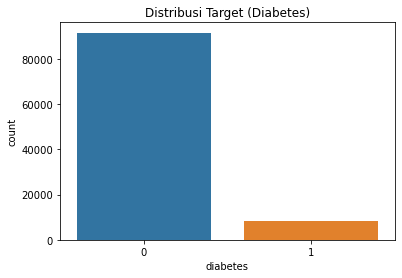

In [3]:
# EDA
print("Info Dataset:")
print(df.info())

print("\nStatistik Deskriptif:")
print(df.describe())

# Cek missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Visualisasi distribusi target
plt.figure(figsize=(6,4))
sns.countplot(x='diabetes', data=df)
plt.title('Distribusi Target (Diabetes)')
plt.show()

In [4]:
# Preprocessing
# Encoding categorical
categorical_cols = ['gender', 'smoking_history']
for col in categorical_cols:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])

X = df.drop('diabetes', axis=1)
y = df['diabetes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Preprocessing selesai.")

Preprocessing selesai.


In [5]:
# ==================== MODELLING WITH MLFLOW ====================

import mlflow
import mlflow.sklearn

# Set experiment name
mlflow.set_experiment("Diabetes_Prediction_Ersa")

with mlflow.start_run(run_name="RandomForest_Tuning"):
    
    # Model
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    
    # Autolog
    mlflow.sklearn.autolog()
    
    # Training
    model.fit(X_train_scaled, y_train)
    
    # Prediction
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    
    print(f"Accuracy: {accuracy:.4f}")
    
    # Log manual metrics (tambahan)
    mlflow.log_metric("accuracy", accuracy)
    
    # Save model
    joblib.dump(model, "best_model.joblib")
    mlflow.log_artifact("best_model.joblib")

print("Modelling dengan MLflow selesai!")

2026/07/05 06:39:11 INFO mlflow.tracking.fluent: Experiment with name 'Diabetes_Prediction_Ersa' does not exist. Creating a new experiment.
2026/07/05 06:39:13 WARNING mlflow.utils.autologging_utils: MLflow sklearn autologging is known to be compatible with 1.3.0 <= scikit-learn <= 1.7.0, but the installed version is 1.0.2. If you encounter errors during autologging, try upgrading / downgrading scikit-learn to a compatible version, or try upgrading MLflow.
2026/07/05 06:39:16 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/07/05 06:39:53 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\ACER\AppData\Local\Temp\tmppeltjp2k\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.0.2', 'cloudpickle==2.0.0']. Set logging level to DEBUG to see the full traceback. 


Accuracy: 0.9708
Modelling dengan MLflow selesai!


In [7]:
import subprocess
subprocess.Popen(["mlflow", "ui"])

<Popen: returncode: None args: ['mlflow', 'ui']>